In [2]:
pip install matplotlib


   ---------------------------------------- 0.0/8.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.0 MB ? eta -:--:--
   - -------------------------------------- 0.3/8.0 MB ? eta -:--:--
   - -------------------------------------- 0.3/8.0 MB ? eta -:--:--
   -- ------------------------------------- 0.5/8.0 MB 512.1 kB/s eta 0:00:15
   -- ------------------------------------- 0.5/8.0 MB 512.1 kB/s eta 0:00:15
   -- ------------------------------------- 0.5/8.0 MB 512.1 kB/s eta 0:00:15
   --- ------------------------------------ 0.8/8.0 MB 559.4 kB/s eta 0:00:13
   ----- ---------------------------------- 1.0/8.0 MB 603.7 kB/s eta 0:00:12
   ----- ---------------------------------- 1.0/8.0 MB 603.7 kB/s eta 0:00:12
   ------ --------------------------------- 1.3/8.0 MB 632.6 kB/s eta 0:00:11
   ------ ------------------------------

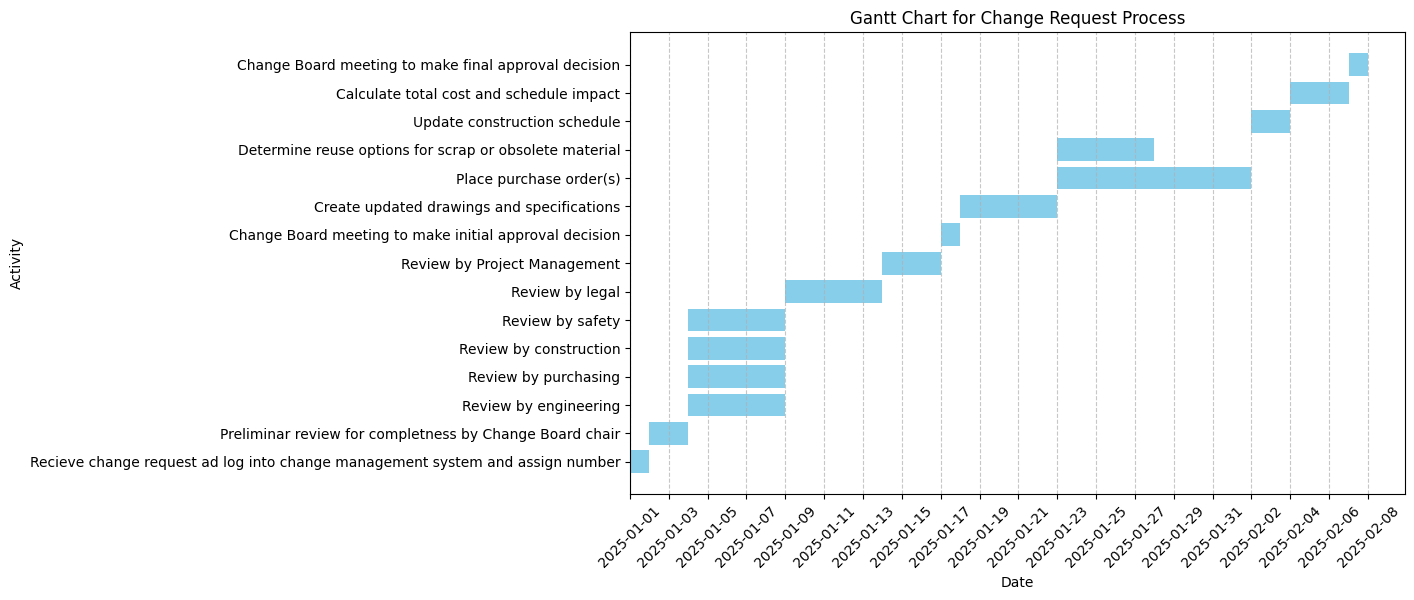

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from datetime import datetime, timedelta

# Define tasks with dependencies and durations
tasks = [
    ("Recieve change request ad log into change management system and assign number", [], 1),
    ("Preliminar review for completness by Change Board chair", [1], 2),
    ("Review by engineering", [2], 5),
    ("Review by purchasing", [2], 5),
    ("Review by construction", [2], 5),
    ("Review by safety", [2], 5),
    ("Review by legal", [2, 4], 5),
    ("Review by Project Management", [3, 4, 5, 6, 7], 3),
    ("Change Board meeting to make initial approval decision", [3, 4, 5, 6, 7, 8], 1),
    ("Create updated drawings and specifications", [9], 5),
    ("Place purchase order(s)", [9, 10], 10),
    ("Determine reuse options for scrap or obsolete material", [9, 10], 5),
    ("Update construction schedule", [10, 11], 2),
    ("Calculate total cost and schedule impact", [10, 11, 12, 13], 3),
    ("Change Board meeting to make final approval decision", [14], 1)
]

# Compute start and end dates based on dependencies
start_dates = {}
end_dates = {}
start_time = datetime(2025, 1, 1)  # Assuming that the tasks started in 2018

for task, dependencies, duration in tasks:
    if not dependencies:
        start_dates[task] = start_time
    else:
        start_dates[task] = max(end_dates[tasks[i-1][0]] for i in dependencies)
    
    end_dates[task] = start_dates[task] + timedelta(days=duration)

# Create a DataFrame for visualization
df = pd.DataFrame({
    "Task": [task[0] for task in tasks],
    "Start": [start_dates[task[0]] for task in tasks],
    "End": [end_dates[task[0]] for task in tasks]
})

# Plot the Gantt chart
fig, ax = plt.subplots(figsize=(10, 6))
for i, (task, start, end) in enumerate(zip(df["Task"], df["Start"], df["End"])):
    ax.barh(task, (end - start).days, left=start, color="skyblue")

# Format x-axis with dates
ax.xaxis.set_major_locator(mdates.DayLocator(interval=2))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d"))
plt.xticks(rotation=45)
plt.xlabel("Date")
plt.ylabel("Activity")
plt.title("Gantt Chart for Change Request Process")
plt.grid(axis="x", linestyle="--", alpha=0.7)
plt.show()